In [1]:
import pandas as pd

In [2]:
data = pd.read_excel(r'C:\Users\GHSP_EDITOR9\Desktop\MPI\nig21_National_office submit1.xlsx')

In [4]:
household_data = data.drop_duplicates(subset='Household ID')

In [6]:
household_size = data.groupby('Household ID')['Individual ID'].count().reset_index()
household_size.columns = ['Household ID', 'HouseholdSize']

In [7]:
household_data = pd.merge(household_data, household_size, on='Household ID')


household_data.reset_index(drop=True, inplace=True)


household_data.to_csv('household_level_data_with_size.csv', index=False)

In [15]:
Df = pd.read_excel(r'C:\Users\GHSP_EDITOR9\Desktop\MPI\household_level_data_with_size.xlsx')

In [3]:
from sklearn.model_selection import train_test_split

In [16]:
random_seed = 42
df1, df2 = train_test_split(Df, test_size=0.5, random_state=random_seed)
df2, df3 = train_test_split(df2, test_size=0.5, random_state=random_seed)

In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25929 entries, 46789 to 15795
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Zone                               25929 non-null  object 
 1   State                              25929 non-null  object 
 2   LGA                                25929 non-null  object 
 3   HH No                              25929 non-null  int64  
 4   Household_ID                       25929 non-null  int64  
 5   Sex                                25929 non-null  object 
 6   Age                                25929 non-null  int64  
 7   HouseholdSize                      25929 non-null  int64  
 8   Nutrition                          25929 non-null  int64  
 9   Food security                      25929 non-null  int64  
 10  Health                             25929 non-null  int64  
 11  School attendance                  25929 non-null 

In [4]:
Df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51859 entries, 0 to 51858
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Zone                               51859 non-null  object 
 1   State                              51859 non-null  object 
 2   LGA                                51859 non-null  object 
 3   HH No                              51859 non-null  int64  
 4   Household_ID                       51859 non-null  int64  
 5   Sex                                51859 non-null  object 
 6   Age                                51859 non-null  int64  
 7   HouseholdSize                      51859 non-null  int64  
 8   Nutrition                          51859 non-null  int64  
 9   Food security                      51859 non-null  int64  
 10  Health                             51859 non-null  int64  
 11  School attendance                  51859 non-null  int

In [5]:
unique_lgas = Df['LGA'].unique()

# Get the total number of unique LGAs
total_lgas = len(unique_lgas)

# Display the total number and each unique LGA
print("Total number of LGAs:", total_lgas)
print("List of LGAs:")
for LGA in unique_lgas:
    print(LGA)

Total number of LGAs: 714
List of LGAs:
ADOR
APA
BURUKU
GBOKO
GUMA
GWER-EAST
GWER-WEST
KATSINA-ALA
KONSHISHA
KWANDE
LOGO
MAKURDI
OBI
OGBADIBO
OHIMINI
OJU
OKPOKWU
OTUKPO
TARKA
UKUM
USHONGO
VANDEIKYA
ADAVI
AJAOKUTA
ANKPA
BASSA
DEKINA
IBAJI
IDAH
IGALAMELA-ODOLU
IJUMU
KABBA/BUNU
KOGI(K.K)
LOKOJA
MOPAMURO
OFU
OKEHI
OKENE
OLAMABORO
OMALA
YAGBA EAST
YAGBA WEST
ASA
BARUTEN
EDU
EKITI
IFELODUN
ILORIN EAST
ILORIN SOUTH
ILORIN WEST
IREPODUN
ISIN
KAIAMA
MORO
OFFA
OKE-ERO
OYUN
PATIGI
AKWANGA
AWE
DOMA
KARU
KEANA
KEFFI
KOKONA
LAFIA
NASARAWA
NASARAWA EGGON
WAMBA
AGAIE
AGWARA
BIDA
BORGU
BOSSO
CHANCHAGA
EDATI-IDATI
GBAKO
GURARA
KATCHA
KONTAGORA
LAPAI
LAVUN
MAGAMA
MASHEGU
MOKWA
PAIKORO
SULEJA
TAFA
WUSHISHI
BARKIN LADI
BOKKOS
JOS EAST
JOS NORTH
JOS SOUTH
KANAM
KANKE
LANTANG NORTH
LANTANG SOUTH
MANGU
MIKANG
PANKSHIN
QUA'AN PAN
RIYOM
SHENDAM
WASE
ABAJI AREA COUNCIL
BWARI AREA COUNCIL
GWAGWALADA AREA COUNCIL
KUJE AREA COUNCIL
KWALI AREA COUNCIL
MUNICIPAL AREA COUNCIL
DEMSA
FUFORE/GURIN
GANYE
GIREI
GOMBI
GUYUK

In [6]:
lga_counts = Df['LGA'].value_counts()

# Filter LGAs with counts greater than 1 (duplicates)
duplicate_lgas = lga_counts[lga_counts > 15]

if not duplicate_lgas.empty:
    print("Duplicate LGAs and their counts:")
    print(duplicate_lgas)
else:
    print("No duplicate LGAs found.")

Duplicate LGAs and their counts:
MUNICIPAL AREA COUNCIL    650
MAIDUGURI METROPOLITAN    326
EKEREMOR                  319
JERE                      267
NASARAWA EGGON            261
                         ... 
ATAKUMOSA WEST             24
EMOHU                      24
ENUGU SOUTH                22
AMUWO-ODOFIN               20
BADAGRY                    19
Name: LGA, Length: 674, dtype: int64


In [7]:
lga_counts = Df['LGA'].value_counts()

# Filter LGAs with counts greater than 15
lgas_with_more_than_15 = lga_counts[lga_counts > 15]

total_lgas_with_more_than_15 = len(lgas_with_more_than_15)

print("Total number of LGAs with more than 15 households:", total_lgas_with_more_than_15)

# Display all LGAs with more than 15 households
if total_lgas_with_more_than_15 > 0:
    print("LGAs with more than 15 households:")
    print(lgas_with_more_than_15.index)

Total number of LGAs with more than 15 households: 674
LGAs with more than 15 households:
Index(['MUNICIPAL AREA COUNCIL', 'MAIDUGURI METROPOLITAN', 'EKEREMOR', 'JERE',
       'NASARAWA EGGON', 'KAURA NAMODA', 'OGBIA', 'NASARAWA', 'AKKO',
       'TALATA MAFARA',
       ...
       'IWAJOWA', 'NKWERE', 'BOLOWADURO', 'WARRI SOUTH WEST',
       'AKOKO SOUTH EAST', 'ATAKUMOSA WEST', 'EMOHU', 'ENUGU SOUTH',
       'AMUWO-ODOFIN', 'BADAGRY'],
      dtype='object', length=674)


In [17]:
Lga_df = Df.groupby('LGA').sum()


total_households = Df.groupby('LGA').size()
Lga_df['total_Nutrition'] = (Lga_df['Nutrition'] / total_households) * 100
Lga_df['total_Food security'] = (Lga_df['Food security'] / total_households) * 100
Lga_df['total_health'] = (Lga_df['Health'] / total_households) * 100
Lga_df['total_School attendance'] = (Lga_df['School attendance'] / total_households) * 100
Lga_df['total_Years of schooling'] = (Lga_df['Years of schooling'] / total_households) * 100
Lga_df['total_School lag'] = (Lga_df['School lag'] / total_households) * 100
Lga_df['total_Water access'] = (Lga_df['Water access'] / total_households) * 100
Lga_df['total_Water reliability'] = (Lga_df['Water reliability'] / total_households) * 100
Lga_df['total_Sanitation'] = (Lga_df['Sanitation'] / total_households) * 100
Lga_df['total_Housing'] = (Lga_df['Housing'] / total_households) * 100
Lga_df['total_Cooking'] = (Lga_df['Cooking'] / total_households) * 100
Lga_df['total_Asset'] = (Lga_df['Asset'] / total_households) * 100
Lga_df['total_Unemployment'] = (Lga_df['Unemployment'] / total_households) * 100
Lga_df['total_Underemployment'] = (Lga_df['Underemployment'] / total_households) * 100
Lga_df['total_Security shock'] = (Lga_df['Security shock'] / total_households) * 100


print(Lga_df)

                    HH No     Household_ID   Age  HouseholdSize  Nutrition  \
LGA                                                                          
ABA NORTH             585  296747493929785  3359            249          2   
ABA SOUTH             934  473192060641134  5352            465          8   
ABAJI AREA COUNCIL    573  100280195085973  2971            375         16   
ABAK                  465  296787760195365  2698            279          9   
ABAKALIKI             719  353554715251519  4033            384         20   
...                   ...              ...   ...            ...        ...   
ZANGO                 228   89656956071628  1425            184         10   
ZANGON KATAF          694  280000352333894  4014            478          4   
ZARIA                 720  286364081795220  4503            778         37   
ZING                  720  210907467036720  3843            435         31   
ZURU                  960  385454541560460  5084            721 

C:\Users\GHSP_EDITOR9\AppData\Local\Temp\ipykernel_9620\2023031098.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  Lga_df = Df.groupby('LGA').sum()


In [50]:
groupby_columns = ['LGA', 'Zone', 'State']


Lga_df = Df.groupby(groupby_columns).sum(numeric_only=True)


total_households = Df.groupby(groupby_columns).size()
Lga_df['total_Nutrition'] = (Lga_df['Nutrition'] / total_households) * 100
Lga_df['total_Food security'] = (Lga_df['Food security'] / total_households) * 100
Lga_df['total_health'] = (Lga_df['Health'] / total_households) * 100
Lga_df['total_School attendance'] = (Lga_df['School attendance'] / total_households) * 100
Lga_df['total_Years of schooling'] = (Lga_df['Years of schooling'] / total_households) * 100
Lga_df['total_School lag'] = (Lga_df['School lag'] / total_households) * 100
Lga_df['total_Water access'] = (Lga_df['Water access'] / total_households) * 100
Lga_df['total_Water reliability'] = (Lga_df['Water reliability'] / total_households) * 100
Lga_df['total_Sanitation'] = (Lga_df['Sanitation'] / total_households) * 100
Lga_df['total_Housing'] = (Lga_df['Housing'] / total_households) * 100
Lga_df['total_Cooking'] = (Lga_df['Cooking'] / total_households) * 100
Lga_df['total_Asset'] = (Lga_df['Asset'] / total_households) * 100
Lga_df['total_Unemployment'] = (Lga_df['Unemployment'] / total_households) * 100
Lga_df['total_Underemployment'] = (Lga_df['Underemployment'] / total_households) * 100
Lga_df['total_Security shock'] = (Lga_df['Security shock'] / total_households) * 100



Lga_df.reset_index(inplace=True)

print(Lga_df)

                    LGA           Zone      State  HH No     Household_ID  \
0             ABA NORTH     SOUTH EAST       ABIA    585  296747493929785   
1             ABA SOUTH     SOUTH EAST       ABIA    934  473192060641134   
2    ABAJI AREA COUNCIL  NORTH CENTRAL  FCT ABUJA    573  100280195085973   
3                  ABAK    SOUTH SOUTH  AKWA IBOM    465  296787760195365   
4             ABAKALIKI     SOUTH EAST     EBONYI    719  353554715251519   
..                  ...            ...        ...    ...              ...   
715               ZANGO     NORTH WEST    KATSINA    228   89656956071628   
716        ZANGON KATAF     NORTH WEST     KADUNA    694  280000352333894   
717               ZARIA     NORTH WEST     KADUNA    720  286364081795220   
718                ZING     NORTH EAST     TARABA    720  210907467036720   
719                ZURU     NORTH WEST      KEBBI    960  385454541560460   

      Age  HouseholdSize  Nutrition  Food security  Health  ...  \
0    335

In [51]:
file_path = (r'C:\Users\GHSP_EDITOR9\Desktop\MPI\Lga_df.xlsx')


Lga_df.to_excel(file_path, index=False)

In [141]:
test1 = pd.read_excel(r'C:\Users\GHSP_EDITOR9\Desktop\MPI\Lga_df.xlsx')

In [142]:
import matplotlib.pyplot as plt
import geopandas as gpd

In [143]:
shp_gdf = gpd.read_file(r'C:\Users\GHSP_EDITOR9\Desktop\MPI\New_Shape_File\nga_admbnda_adm2_osgof_20170222.shp', as_dataframe=True)
shp_gdf.head()

,admin2Name,admin2Pcod,admin2RefN,admin2AltN,admin2Al_1,admin1Name,admin1Pcod,admin0Name,admin0Pcod,date,validOn,ValidTo,Shape_Leng,Shape_Area,geometry
0,Aba North,NG001001,Aba North,NaN,NaN,Abia,NG001,Nigeria,NG,2016-11-29,2017-02-22,NaN,0.237074,0.001524,"POLYGON ((7.40111 5.08195, 7.40013 5.08237, 7...."
1,Aba South,NG001002,Aba South,NaN,NaN,Abia,NG001,Nigeria,NG,2016-11-29,2017-02-22,NaN,0.262477,0.003531,"POLYGON ((7.38749 5.08275, 7.38632 5.08236, 7...."
2,Abaji,NG015001,Abaji,NaN,NaN,Federal Capital Territory,NG015,Nigeria,NG,2016-11-29,2017-02-22,NaN,2.537984,0.068379,"POLYGON ((7.04587 9.23050, 7.02654 9.22216, 7...."
3,Abak,NG003001,Abak,NaN,NaN,Akwa Ibom,NG003,Nigeria,NG,2016-11-29,2017-02-22,NaN,0.687150,0.014529,"POLYGON ((7.81124 5.09453, 7.81233 5.09367, 7...."
4,Abakaliki,NG011001,Abakaliki,NaN,NaN,Ebonyi,NG011,Nigeria,NG,2016-11-29,2017-02-22,NaN,1.062415,0.037865,"POLYGON ((8.41090 6.28212, 8.41285 6.27915, 8...."


In [144]:
shp_gdf['admin2Name'] = shp_gdf['admin2Name'].str.upper()

In [145]:
shp_gdf.head()

,admin2Name,admin2Pcod,admin2RefN,admin2AltN,admin2Al_1,admin1Name,admin1Pcod,admin0Name,admin0Pcod,date,validOn,ValidTo,Shape_Leng,Shape_Area,geometry
0,ABA NORTH,NG001001,Aba North,NaN,NaN,Abia,NG001,Nigeria,NG,2016-11-29,2017-02-22,NaN,0.237074,0.001524,"POLYGON ((7.40111 5.08195, 7.40013 5.08237, 7...."
1,ABA SOUTH,NG001002,Aba South,NaN,NaN,Abia,NG001,Nigeria,NG,2016-11-29,2017-02-22,NaN,0.262477,0.003531,"POLYGON ((7.38749 5.08275, 7.38632 5.08236, 7...."
2,ABAJI,NG015001,Abaji,NaN,NaN,Federal Capital Territory,NG015,Nigeria,NG,2016-11-29,2017-02-22,NaN,2.537984,0.068379,"POLYGON ((7.04587 9.23050, 7.02654 9.22216, 7...."
3,ABAK,NG003001,Abak,NaN,NaN,Akwa Ibom,NG003,Nigeria,NG,2016-11-29,2017-02-22,NaN,0.687150,0.014529,"POLYGON ((7.81124 5.09453, 7.81233 5.09367, 7...."
4,ABAKALIKI,NG011001,Abakaliki,NaN,NaN,Ebonyi,NG011,Nigeria,NG,2016-11-29,2017-02-22,NaN,1.062415,0.037865,"POLYGON ((8.41090 6.28212, 8.41285 6.27915, 8...."


In [146]:
column_rename = {'admin2Name': 'LGA'}
shp_gdf.rename(columns=column_rename, inplace=True)

In [147]:
merged_data = shp_gdf.merge(test1, on='LGA')

In [148]:
merged_data.head()

,LGA,admin2Pcod,admin2RefN,admin2AltN,admin2Al_1,admin1Name,admin1Pcod,admin0Name,admin0Pcod,date,...,total_School lag,total_Water access,total_Water reliability,total_Sanitation,total_Housing,total_Cooking,total_Asset,total_Unemployment,total_Underemployment,total_Security shock
0,ABA NORTH,NG001001,Aba North,NaN,NaN,Abia,NG001,Nigeria,NG,2016-11-29,...,0.000000,0.000000,10.810811,8.108108,0.000000,9.459459,1.351351,5.405405,1.351351,2.702703
1,ABA SOUTH,NG001002,Aba South,NaN,NaN,Abia,NG001,Nigeria,NG,2016-11-29,...,2.542373,0.000000,25.423729,30.508475,0.000000,34.745763,7.627119,19.491525,3.389831,5.932203
2,ABAJI,NG015001,Abaji,NaN,NaN,Federal Capital Territory,NG015,Nigeria,NG,2016-11-29,...,6.849315,46.575342,6.849315,50.684932,31.506849,52.054795,19.178082,12.328767,6.849315,2.739726
3,ABAK,NG003001,Abak,NaN,NaN,Akwa Ibom,NG003,Nigeria,NG,2016-11-29,...,6.779661,8.474576,49.152542,35.593220,30.508475,66.101695,16.949153,33.898305,52.542373,16.949153
4,ABAKALIKI,NG011001,Abakaliki,NaN,NaN,Ebonyi,NG011,Nigeria,NG,2016-11-29,...,13.953488,29.069767,31.395349,60.465116,25.581395,65.116279,32.558140,22.093023,12.790698,16.279070


In [149]:
columns_to_drop = ['admin2Pcod', 'admin2RefN', 'admin2AltN', 'admin2Al_1', 'admin1Name', 'admin1Pcod', 'admin0Name', 'admin0Pcod', 'date', 'validOn', 'ValidTo']
merged_data.drop(columns_to_drop, axis=1, inplace=True)

In [150]:
merged_data.info

<bound method DataFrame.info of              LGA  Shape_Leng  Shape_Area  \
0      ABA NORTH    0.237074    0.001524   
1      ABA SOUTH    0.262477    0.003531   
2          ABAJI    2.537984    0.068379   
3           ABAK    0.687150    0.014529   
4      ABAKALIKI    1.062415    0.037865   
..           ...         ...         ...   
694  KWAYA KUSAR    1.119672    0.061709   
695         MAFA    2.460498    0.236870   
696    MAIDUGURI    0.519518    0.011603   
697       MOBBAR    2.534845    0.225422   
698        SHANI    1.508631    0.101077   

                                              geometry           Zone  \
0    POLYGON ((7.40111 5.08195, 7.40013 5.08237, 7....     SOUTH EAST   
1    POLYGON ((7.38749 5.08275, 7.38632 5.08236, 7....     SOUTH EAST   
2    POLYGON ((7.04587 9.23050, 7.02654 9.22216, 7....  NORTH CENTRAL   
3    POLYGON ((7.81124 5.09453, 7.81233 5.09367, 7....    SOUTH SOUTH   
4    POLYGON ((8.41090 6.28212, 8.41285 6.27915, 8....     SOUTH EAST   
.

In [33]:
merged_data.value_counts

<bound method DataFrame.value_counts of              LGA admin2Pcod   admin2RefN  admin2AltN  admin2Al_1  \
0      ABA NORTH   NG001001    Aba North         NaN         NaN   
1      ABA SOUTH   NG001002    Aba South         NaN         NaN   
2          ABAJI   NG015001        Abaji         NaN         NaN   
3           ABAK   NG003001         Abak         NaN         NaN   
4      ABAKALIKI   NG011001    Abakaliki         NaN         NaN   
..           ...        ...          ...         ...         ...   
686  KWAYA KUSAR   NG008018  Kwaya Kusar         NaN         NaN   
687         MAFA   NG008019         Mafa         NaN         NaN   
688    MAIDUGURI   NG008021    Maiduguri         NaN         NaN   
689       MOBBAR   NG008023       Mobbar         NaN         NaN   
690        SHANI   NG008027        Shani         NaN         NaN   

                    admin1Name admin1Pcod admin0Name admin0Pcod        date  \
0                         Abia      NG001    Nigeria         NG 

In [140]:
filtered_gdf = shp_gdf[shp_gdf['admin1Name'] == 'Borno']
print(filtered_gdf)

             LGA admin2Pcod   admin2RefN  admin2AltN  admin2Al_1 admin1Name  \
747       ABADAM   NG008001       Abadam         NaN         NaN      Borno   
748   ASKIRA/UBA   NG008002   Askira/Uba         NaN         NaN      Borno   
749         BAMA   NG008003         Bama         NaN         NaN      Borno   
750         BAYO   NG008004         Bayo         NaN         NaN      Borno   
751          BIU   NG008005          Biu         NaN         NaN      Borno   
752       CHIBOK   NG008006       Chibok         NaN         NaN      Borno   
753       DAMBOA   NG008007       Damboa         NaN         NaN      Borno   
754        DIKWA   NG008008        Dikwa         NaN         NaN      Borno   
755        GUBIO   NG008009        Gubio         NaN         NaN      Borno   
756     GUZAMALA   NG008010     Guzamala         NaN         NaN      Borno   
757        GWOZA   NG008011        Gwoza         NaN         NaN      Borno   
758        HAWUL   NG008012        Hawul         NaN

In [159]:
merged_data.info

<bound method DataFrame.info of              LGA  Shape_Leng  Shape_Area  \
0      ABA NORTH    0.237074    0.001524   
1      ABA SOUTH    0.262477    0.003531   
2          ABAJI    2.537984    0.068379   
3           ABAK    0.687150    0.014529   
4      ABAKALIKI    1.062415    0.037865   
..           ...         ...         ...   
694  KWAYA KUSAR    1.119672    0.061709   
695         MAFA    2.460498    0.236870   
696    MAIDUGURI    0.519518    0.011603   
697       MOBBAR    2.534845    0.225422   
698        SHANI    1.508631    0.101077   

                                              geometry           Zone  \
0    POLYGON ((7.40111 5.08195, 7.40013 5.08237, 7....     SOUTH EAST   
1    POLYGON ((7.38749 5.08275, 7.38632 5.08236, 7....     SOUTH EAST   
2    POLYGON ((7.04587 9.23050, 7.02654 9.22216, 7....  NORTH CENTRAL   
3    POLYGON ((7.81124 5.09453, 7.81233 5.09367, 7....    SOUTH SOUTH   
4    POLYGON ((8.41090 6.28212, 8.41285 6.27915, 8....     SOUTH EAST   
.

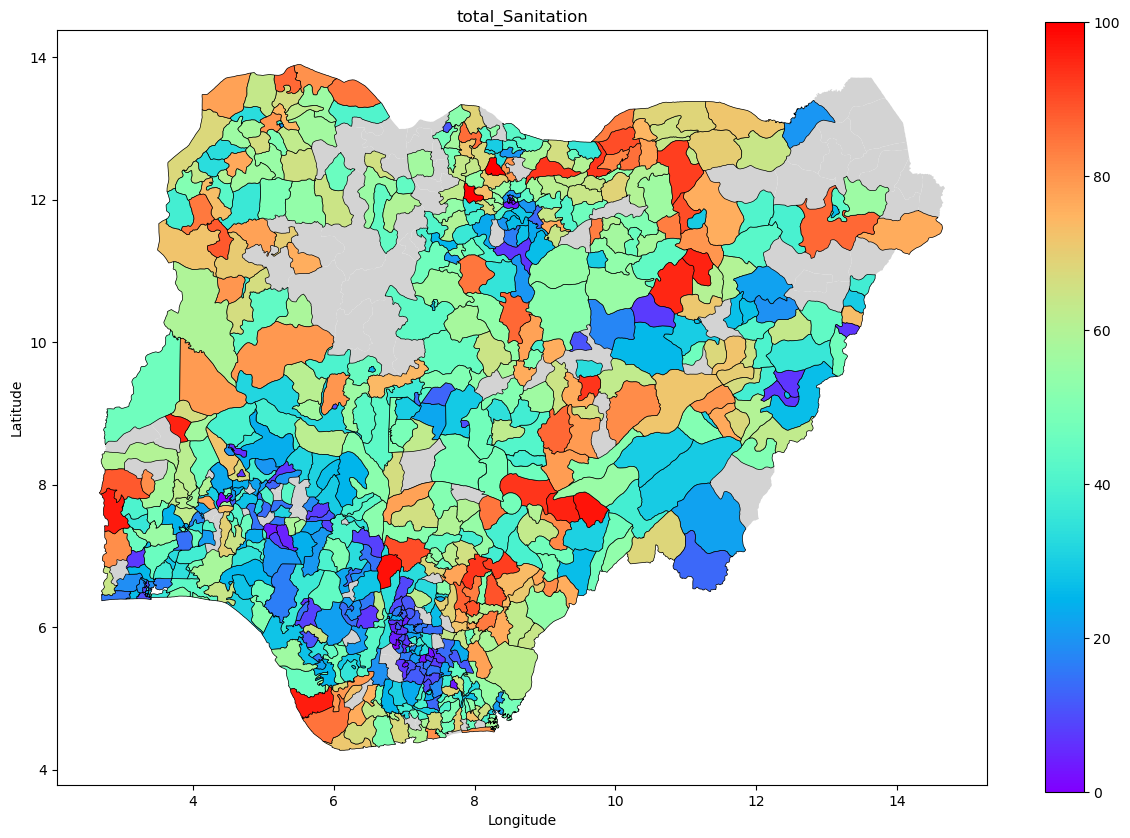

In [158]:
import geopandas as gpd
import matplotlib.pyplot as plt



fig, ax = plt.subplots(figsize=(15, 10))

# full map of all LGAs
shp_gdf.plot(ax=ax, color='lightgray')


#  values of 'total_food_insecure' on the map
merged_data.plot(column='total_Sanitation', cmap='rainbow', linewidth=0.5, edgecolor='black', legend=True, ax=ax)


# title and axis labels
ax.set_title('total_Sanitation')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')



plt.show()

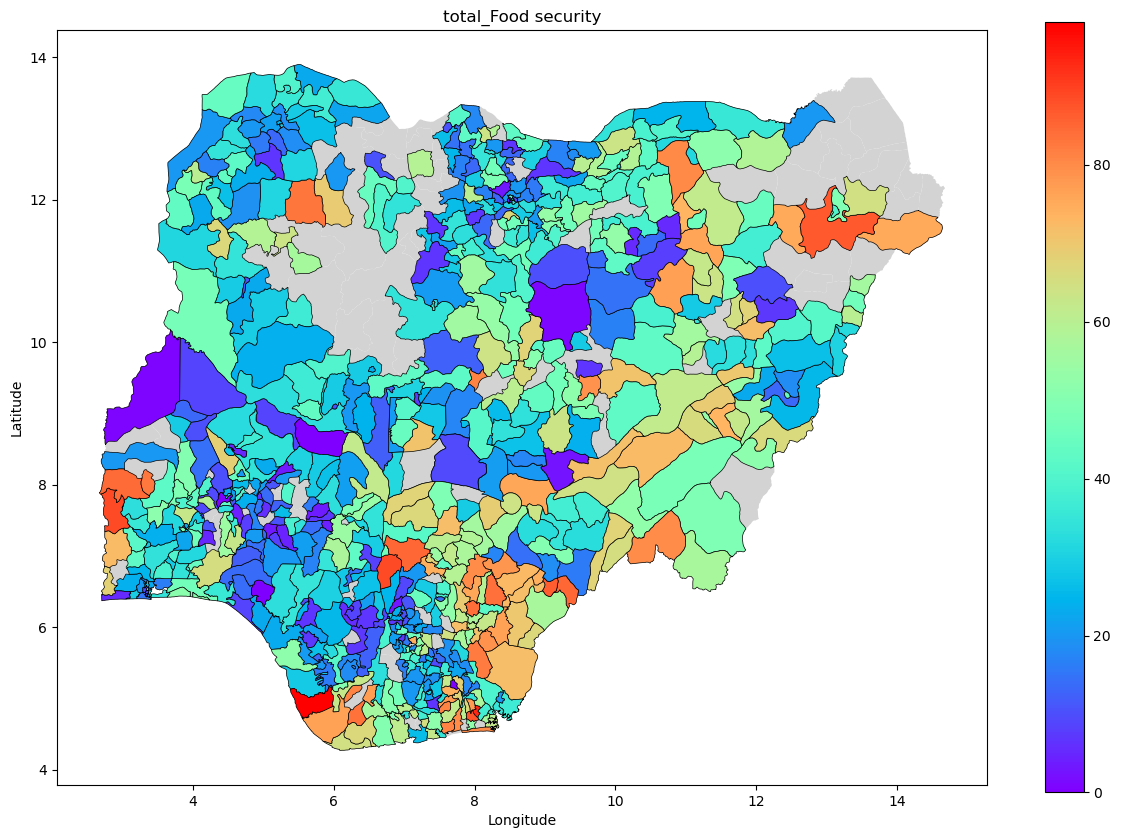

In [160]:
fig, ax = plt.subplots(figsize=(15, 10))

# full map of all LGAs
shp_gdf.plot(ax=ax, color='lightgray')


#  values of 'total_food_insecure' on the map
merged_data.plot(column='total_Food security', cmap='rainbow', linewidth=0.5, edgecolor='black', legend=True, ax=ax)


# title and axis labels
ax.set_title('total_Food security')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')



plt.show()

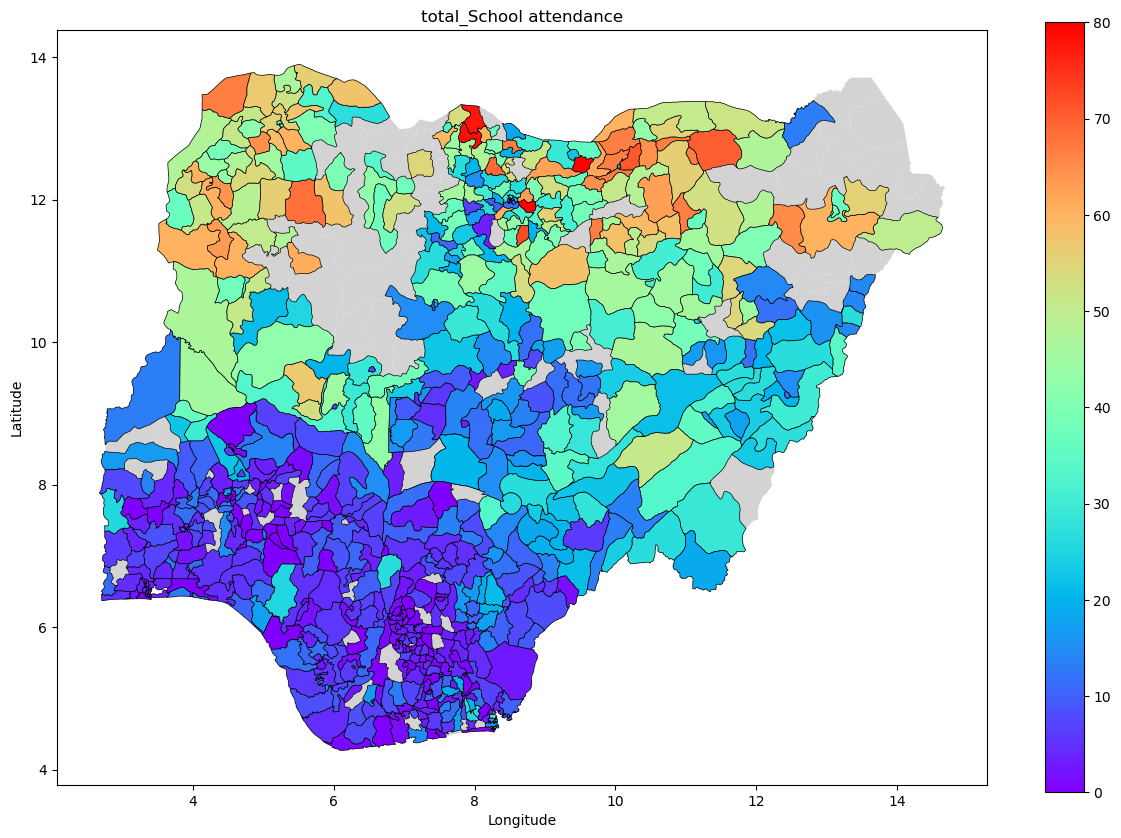

In [161]:
fig, ax = plt.subplots(figsize=(15, 10))

# full map of all LGAs
shp_gdf.plot(ax=ax, color='lightgray')


#  values of 'total_food_insecure' on the map
merged_data.plot(column='total_School attendance', cmap='rainbow', linewidth=0.5, edgecolor='black', legend=True, ax=ax)


# title and axis labels
ax.set_title('total_School attendance')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')



plt.show()

In [164]:
Df.columns.tolist()

['Zone',
 'State',
 'LGA',
 'HH No',
 'Household_ID',
 'Sex',
 'Age',
 'HouseholdSize',
 'Nutrition',
 'Food security',
 'Health',
 'School attendance',
 'Years of schooling',
 'School lag',
 'Water access',
 'Water reliability',
 'Sanitation',
 'Housing',
 'Cooking',
 'Asset',
 'Unemployment',
 'Underemployment',
 'Security shock',
 'Counting Vector',
 'Poverty Identification with k=26%',
 'MPI Identification with k=26%',
 'Individual Weight',
 'Household Weight',
 'Population Weight']

In [19]:
columns_to_drop = ['Zone', 'State', 'LGA', 'HH No', 'Household_ID', 
                   'Age', 'Sex', 'Counting Vector', 'HouseholdSize', 'MPI Identification with k=26%',
                   'Individual Weight', 'Household Weight', 'Population Weight']
Df.drop(columns_to_drop, axis=1, inplace=True)

In [20]:
corr_matrix = Df.corr()
print(corr_matrix)

                                   Nutrition  Food security    Health  \
Nutrition                           1.000000       0.201217  0.238835   
Food security                       0.201217       1.000000  0.362146   
Health                              0.238835       0.362146  1.000000   
School attendance                   0.289646       0.146703  0.204689   
Years of schooling                  0.096505       0.140986  0.220152   
School lag                          0.164159       0.186750  0.173710   
Water access                        0.198225       0.315731  0.382285   
Water reliability                   0.163673       0.265300  0.201688   
Sanitation                          0.292386       0.493657  0.494482   
Housing                             0.350330       0.311851  0.420280   
Cooking                             0.350250       0.497561  0.506122   
Asset                               0.165550       0.370439  0.330764   
Unemployment                        0.069401       

In [5]:
import seaborn as sns

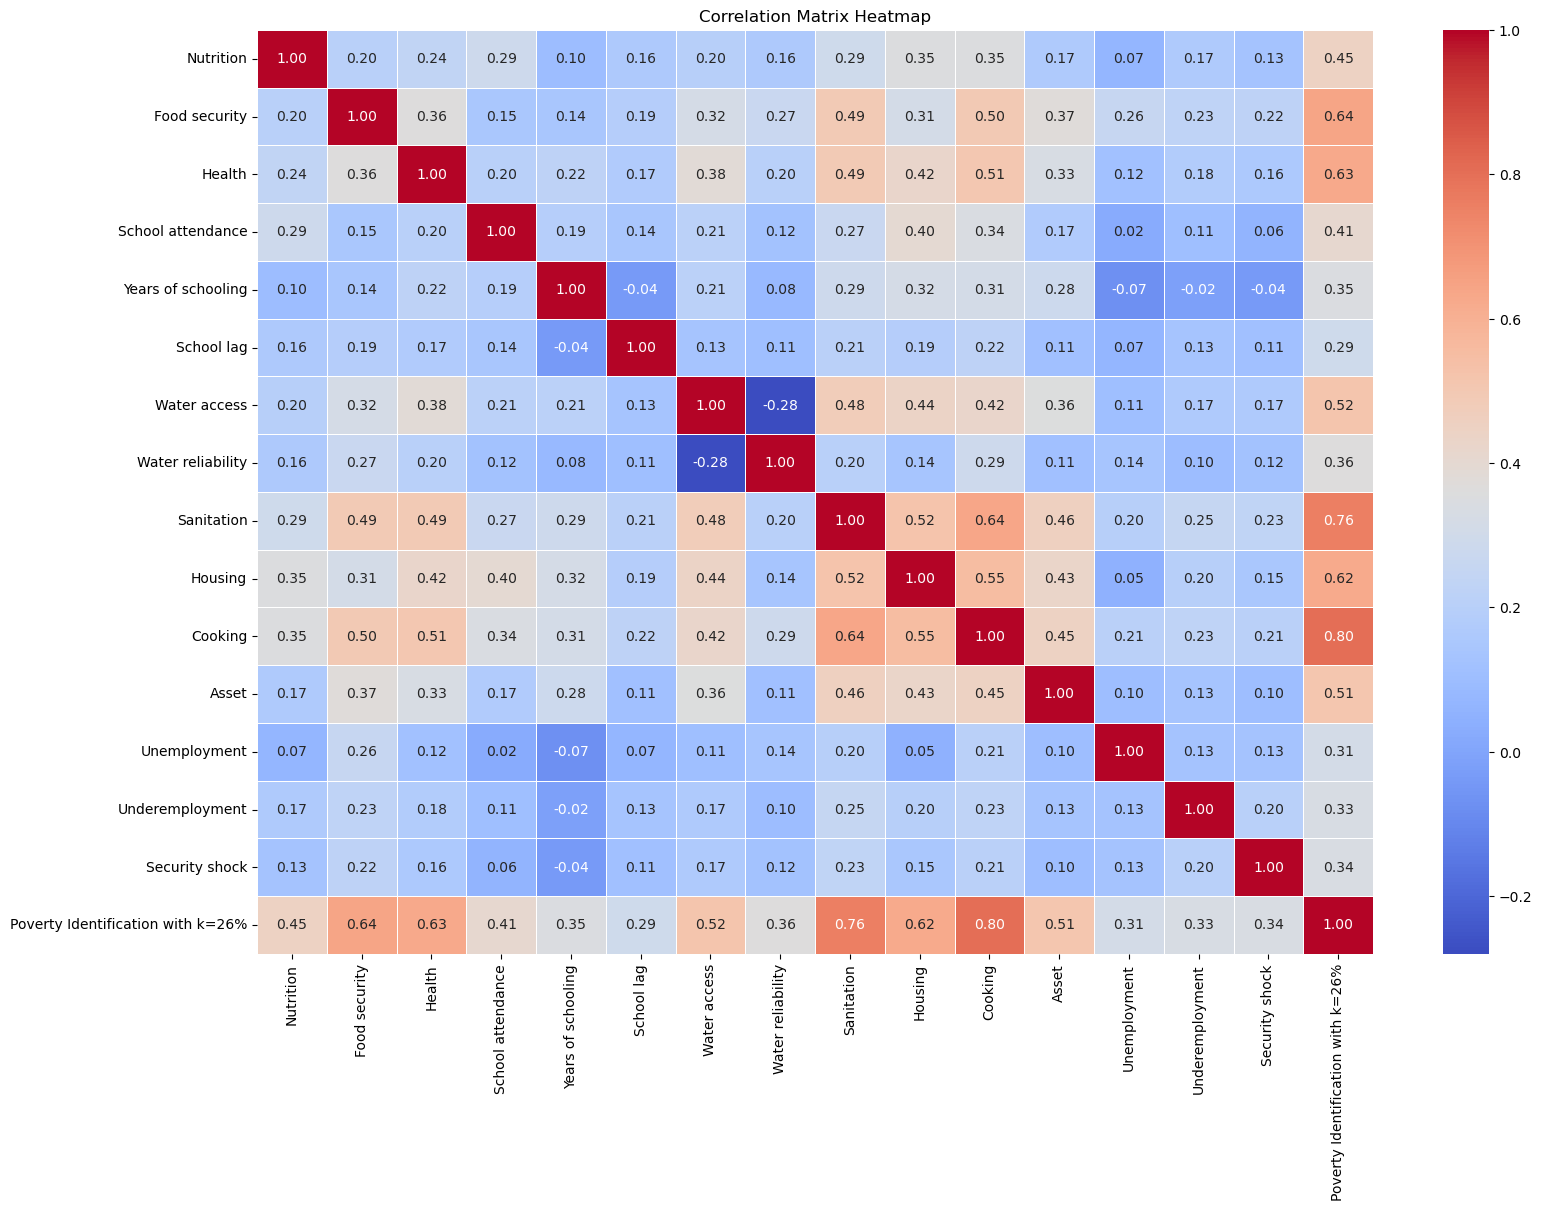

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [5]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

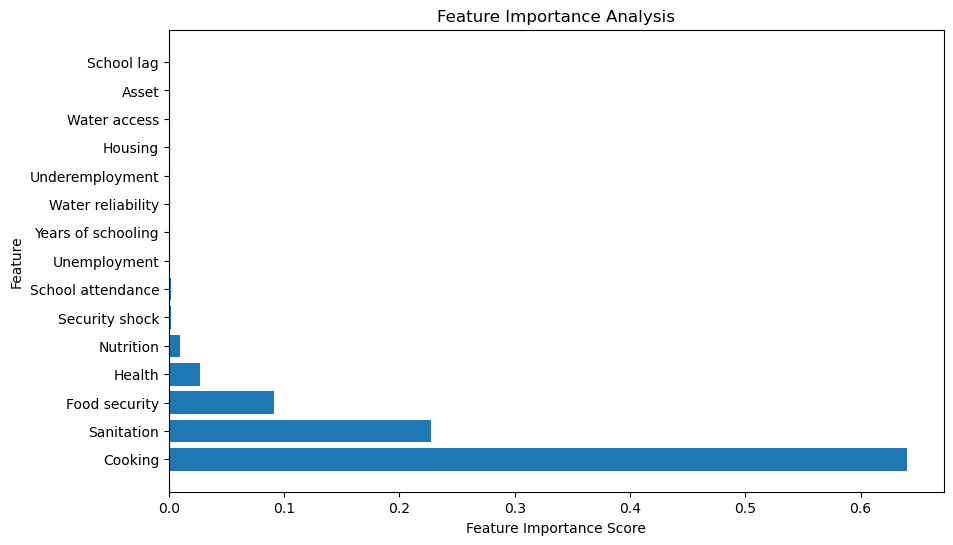

In [23]:
X = Df.drop(columns=['Poverty Identification with k=26%'])  # Exclude the target variable

# Target variable
y = Df['Poverty Identification with k=26%']

# Initialize the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X, y)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame to store feature names and their importance scores
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance Analysis')
plt.show()

In [7]:
Df.columns.tolist()

['Nutrition',
 'Food security',
 'Health',
 'School attendance',
 'Years of schooling',
 'School lag',
 'Water access',
 'Water reliability',
 'Sanitation',
 'Housing',
 'Cooking',
 'Asset',
 'Unemployment',
 'Underemployment',
 'Security shock',
 'Poverty Identification with k=26%',
 'MPI Identification with k=26%',
 'Individual Weight',
 'Household Weight',
 'Population Weight']

In [18]:
columns_to_drop = ['Zone', 'State', 'LGA', 'HH No', 'Household_ID', 
                   'Age', 'Sex', 'HouseholdSize', 'Counting Vector', 'MPI Identification with k=26%', 'Individual Weight', 'Household Weight', 'Population Weight']
df1.drop(columns_to_drop, axis=1, inplace=True)

In [19]:
columns_to_drop = ['Zone', 'State', 'LGA', 'HH No', 'Household_ID', 
                   'Age', 'Sex', 'HouseholdSize', 'Counting Vector', 'MPI Identification with k=26%', 'Individual Weight', 'Household Weight', 'Population Weight']
df2.drop(columns_to_drop, axis=1, inplace=True)

In [20]:
columns_to_drop = ['Zone', 'State', 'LGA', 'HH No', 'Household_ID', 
                   'Age', 'Sex', 'HouseholdSize', 'Counting Vector', 'MPI Identification with k=26%', 'Individual Weight', 'Household Weight', 'Population Weight']
df3.drop(columns_to_drop, axis=1, inplace=True)

In [21]:
column_rename = {'Poverty Identification with k=26%': 'Poverty'}
df1.rename(columns=column_rename, inplace=True)

column_rename = {'Poverty Identification with k=26%': 'Poverty'}
df2.rename(columns=column_rename, inplace=True)

column_rename = {'Poverty Identification with k=26%': 'Poverty'}
df3.rename(columns=column_rename, inplace=True)

In [18]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25929 entries, 46789 to 15795
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Nutrition           25929 non-null  int64
 1   Food security       25929 non-null  int64
 2   Health              25929 non-null  int64
 3   School attendance   25929 non-null  int64
 4   Years of schooling  25929 non-null  int64
 5   School lag          25929 non-null  int64
 6   Water access        25929 non-null  int64
 7   Water reliability   25929 non-null  int64
 8   Sanitation          25929 non-null  int64
 9   Housing             25929 non-null  int64
 10  Cooking             25929 non-null  int64
 11  Asset               25929 non-null  int64
 12  Unemployment        25929 non-null  int64
 13  Underemployment     25929 non-null  int64
 14  Security shock      25929 non-null  int64
dtypes: int64(15)
memory usage: 3.2 MB


In [35]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12965 entries, 10422 to 40624
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Nutrition                          12965 non-null  int64  
 1   Food security                      12965 non-null  int64  
 2   Health                             12965 non-null  int64  
 3   School attendance                  12965 non-null  int64  
 4   Years of schooling                 12965 non-null  int64  
 5   School lag                         12965 non-null  int64  
 6   Water access                       12965 non-null  int64  
 7   Water reliability                  12965 non-null  int64  
 8   Sanitation                         12965 non-null  int64  
 9   Housing                            12965 non-null  int64  
 10  Asset                              12965 non-null  int64  
 11  Unemployment                       12965 non-null 

In [33]:
threshold = 0.26  # Adjust the threshold as needed
df2['Poverty Identification with k=26%'] = (df2['MPI Identification with k=26%'] <= threshold).astype(int)

# Select features (X) and target variable (y)
X = df2.drop(columns=['MPI Identification with k=26%', 'Poverty Identification with k=26%'])  # Exclude MPI_Score and Is_Poor
y = df2['Poverty Identification with k=26%']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [34]:
# Initialize the Random Forest Classifier (you can choose a different model)
rf_classifier = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(report)

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1562
           1       1.00      1.00      1.00      1031

    accuracy                           1.00      2593
   macro avg       1.00      1.00      1.00      2593
weighted avg       1.00      1.00      1.00      2593



In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
X = df3.drop('Poverty', axis=1)
y = df3['Poverty']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


random_forest = RandomForestClassifier(n_estimators=50, random_state=42)

random_forest.fit(X_train, y_train)

y_pred = random_forest.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# a confusion matrix to understand the model's performance on each class
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print(X_train, 'xxxxxx')
print(y_train, 'yyyyy')

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1054
           1       1.00      1.00      1.00      1539

    accuracy                           1.00      2593
   macro avg       1.00      1.00      1.00      2593
weighted avg       1.00      1.00      1.00      2593

Confusion Matrix:
[[1054    0]
 [   0 1539]]
       Nutrition  Food security  Health  School attendance  \
28238          0              0       0                  0   
36423          0              1       1                  0   
16894          0              1       0                  1   
38860          0              0       0                  0   
26318          1              0       1                  0   
...          ...            ...     ...                ...   
44856          0              0       0                  0   
11714          0              0       0                  0   
37516          0              0 

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming df1 and df2 are your DataFrames
# df1 is the testing data, and df2 is the training data

# Separate the features (X) and target (y) from df1 and df2
X_train = df2.drop('Poverty', axis=1)  # Adjust 'target_column_name' to your target variable's name
y_train = df2['Poverty']

X_test = df1.drop('Poverty', axis=1)  # Adjust 'target_column_name' to your target variable's name
y_test = df1['Poverty']

# Initialize the Random Forest Classifier
clf = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters as needed

# Train the model on the training data
clf.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
confusion_mat = confusion_matrix(y_test, y_pred)

# Print the evaluation results
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(confusion_mat)

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10472
           1       1.00      1.00      1.00     15457

    accuracy                           1.00     25929
   macro avg       1.00      1.00      1.00     25929
weighted avg       1.00      1.00      1.00     25929

Confusion Matrix:
[[10472     0]
 [    0 15457]]


In [58]:
pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [27]:
Pred_df = pd.read_excel(r'C:\Users\GHSP_EDITOR9\Desktop\MPI\household_level_data.xlsx')

In [31]:
Project2 = Df.head(40)

In [32]:
file_path = (r'C:\Users\GHSP_EDITOR9\Desktop\MPI\Project2.xlsx')


Project2.to_excel(file_path, index=False)

In [3]:
import joblib

In [ ]:
joblib.dump(RandomForestClassifier, 'MPI_Model.pkl')

In [5]:
import joblib


model = joblib.load('MPI_Model.pkl')

In [12]:
batch_size = 5000  # Adjust batch size as needed
predictions = []

for i in range(0, len(Pred_df), batch_size):
    batch = Df[i:i + batch_size]
    # Convert to numpy array and make predictions
    input_array = np.array(batch)
    
#     batch_predictions = model.predict(input_array)
    
#     # Collect batch predictions
#     predictions.extend(batch_predictions)

print(input_array)


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]]


In [1]:
import pandas as pd
import numpy as np
import joblib

In [2]:
model = joblib.load('MPI_Model.pkl')

In [6]:
new_data_processed = pd.read_excel(r'C:\Users\GHSP_EDITOR9\Desktop\MPI\household_level_data.xlsx')

In [8]:
batch_size = 5000  # Adjust batch size as needed
predictions = []

for i in range(0, len(new_data_processed), batch_size):
    batch = new_data_processed[i:i + batch_size]
    
    # Convert the batch to a numpy array and make predictions
    input_array = np.array(batch)
    print (input_array)


[[0 0 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 1 1 ... 0 1 0]
 ...
 [0 1 1 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 1 ... 1 0 1]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 1 1 ... 1 0 1]
 [0 1 1 ... 0 0 0]
 [0 1 1 ... 0 0 0]]
[[1 1 1 ... 0 0 0]
 [0 1 1 ... 0 0 0]
 [1 0 1 ... 0 0 1]
 ...
 [0 1 1 ... 0 0 0]
 [1 0 1 ... 0 1 0]
 [0 0 1 ... 0 1 0]]
[[0 0 1 ... 0 1 0]
 [1 0 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 ...
 [1 0 0 ... 0 1 0]
 [0 1 0 ... 0 0 1]
 [1 0 0 ... 0 0 1]]
[[0 0 0 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [0 1 1 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
[[1 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 1 0 ... 0 1 1]
 [0 1 0 ... 0 0 1]
 [0 1 0 ... 0 1 1]]
[[0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [

In [ ]:
    batch_predictions = model.predict(input_array)
    
    # Collect batch predictions
    predictions.extend(batch_predictions)

In [8]:
input_data = {
    'Nutrition': 'Nutrition',
    'Food security': 'Food security',
    'Health': 'Health',
    'School attendance': 'School attendance',
    'Years of schooling': 'Years of schooling',
    'Water access': 'Water access',
    'Water reliability': 'Water reliability',
    'Sanitation': 'Sanitation',
    'Housing': 'Housing',
    'Cooking': 'Cooking',
    'Asset': 'Asset',
    'Unemployment': 'Unemployment',
    'Underemployment': 'Underemployment',
    'Security shock': 'Security shock',
}

In [10]:
import numpy as np

In [11]:
input_values = list(input_data.values())

In [12]:
input_array = np.array(input_values).reshape(1, -1)

In [14]:
import pickle
pickle.dump(clf,open("RandomForestClassifier.sav", "wb"))

In [1]:
pip install django

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install PyQt5

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [50]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initializing the SVM classifier
clf_svm = SVC(kernel='rbf', random_state=42)  # You can adjust kernel and other hyperparameters

# Training the SVM model on the training data
clf_svm.fit(X_train, y_train)

# Making predictions on the testing data
y_pred_svm = clf_svm.predict(X_test)

# Evaluating the SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
classification_rep_svm = classification_report(y_test, y_pred_svm)
confusion_mat_svm = confusion_matrix(y_test, y_pred_svm)

# Printing the evaluation results for SVM
print("Support Vector Machine (SVM) Model:")
print(f"Accuracy: {accuracy_svm:.2f}")
print("Classification Report:")
print(classification_rep_svm)
print("Confusion Matrix:")
print(confusion_mat_svm)

Support Vector Machine (SVM) Model:
Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10472
           1       1.00      1.00      1.00     15457

    accuracy                           1.00     25929
   macro avg       1.00      1.00      1.00     25929
weighted avg       1.00      1.00      1.00     25929

Confusion Matrix:
[[10472     0]
 [    0 15457]]


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


clf_lr = LogisticRegression(random_state=42)  # You can adjust hyperparameters


clf_lr.fit(X_train, y_train)


y_pred_lr = clf_lr.predict(X_test)


accuracy_lr = accuracy_score(y_test, y_pred_lr)
classification_rep_lr = classification_report(y_test, y_pred_lr)
confusion_mat_lr = confusion_matrix(y_test, y_pred_lr)


print("Logistic Regression Model:")
print(f"Accuracy: {accuracy_lr:.2f}")
print("Classification Report:")
print(classification_rep_lr)
print("Confusion Matrix:")
print(confusion_mat_lr)

Logistic Regression Model:
Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10472
           1       1.00      1.00      1.00     15457

    accuracy                           1.00     25929
   macro avg       1.00      1.00      1.00     25929
weighted avg       1.00      1.00      1.00     25929

Confusion Matrix:
[[10472     0]
 [    0 15457]]


In [52]:
class_distribution = df1['Poverty Identification with k=26%'].value_counts()


print(class_distribution)

1    15457
0    10472
Name: Poverty Identification with k=26%, dtype: int64


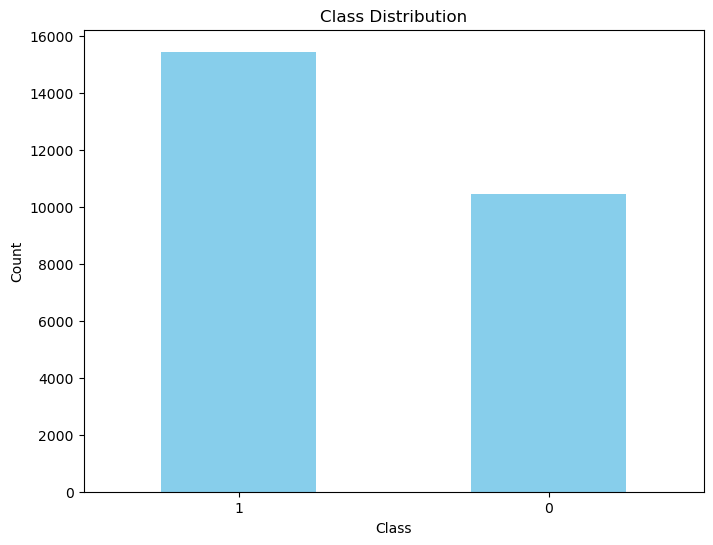

In [53]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
class_distribution.plot(kind='bar', color='skyblue')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Rotate x-axis labels if needed
plt.show()

In [57]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier  # Replace with your chosen model

# Defining the model
model = LogisticRegression(random_state=42)  # You can replace this with your model

# Defining the number of folds for cross-validation (e.g., 5 or 10)
k_folds = 10

# Creating a cross-validation object (StratifiedKFold is suitable for classification tasks)
cv = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Performing cross-validation and compute accuracy scores
cross_val_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

# Printing the accuracy scores for each fold
print("Accuracy Scores for Each Fold:", cross_val_scores)

# Calculating the mean accuracy and standard deviation
mean_accuracy = cross_val_scores.mean()
std_deviation = cross_val_scores.std()

# Printing the mean accuracy and standard deviation
print("Mean Accuracy:", mean_accuracy)
print("Standard Deviation:", std_deviation)

Accuracy Scores for Each Fold: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean Accuracy: 1.0
Standard Deviation: 0.0


In [29]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [30]:
threshold = 0.26  
Df['Poverty Identification with k=26%'] = (Df['MPI Identification with k=26%'] <= threshold).astype(int)

# Select features (X) and target variable (y)
X = Df.drop(columns=['MPI Identification with k=26%', 'Poverty Identification with k=26%'])  # Exclude MPI_Score and Is_Poor
y = Df['Poverty Identification with k=26%']


# Initializing the Random Forest Classifier 
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Specifying the cross-validation strategy (Stratified K-Fold is suitable for binary classification)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Performing cross-validation and calculate accuracy scores
accuracy_scores = cross_val_score(rf_classifier, X, y, scoring='accuracy', cv=cv)


print("Accuracy Scores for Each Fold:", accuracy_scores)

# Calculating mean accuracy and standard deviation
mean_accuracy = accuracy_scores.mean()
std_accuracy = accuracy_scores.std()
print(f"Mean Accuracy: {mean_accuracy:.2f}")
print(f"Standard Deviation: {std_accuracy:.2f}")

Accuracy Scores for Each Fold: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.00
Standard Deviation: 0.00


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [32]:

threshold = 0.26  
Df['Poverty Identification with k=26%'] = (Df['MPI Identification with k=26%'] <= threshold).astype(int)


X = Df.drop(columns=['MPI Identification with k=26%', 'Poverty Identification with k=26%'])  # Exclude MPI_Score and Is_Poor
y = Df['Poverty Identification with k=26%']



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)


gb_classifier.fit(X_train, y_train)

# predictions on the test data
y_pred = gb_classifier.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# classification report for additional metrics
classification_rep = classification_report(y_test, y_pred)
print("Classification Report:")
print(classification_rep)

Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6213
           1       1.00      1.00      1.00      4159

    accuracy                           1.00     10372
   macro avg       1.00      1.00      1.00     10372
weighted avg       1.00      1.00      1.00     10372

